# K-Nearest-Neighbors

👇 `data` klasöründe bulunan `houses_clean.csv` dataset'ini yükleyin  
Veya doğrudan bu URL'den yükleyebilirsiniz: [https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv).  

Dataset açıklaması dataset-description.md dosyasında bulunabilir.

In [1]:
import pandas as pd

url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_clean.csv"

df = pd.read_csv(url)

print(df.head())
print(df.info())

   GrLivArea  BedroomAbvGr  KitchenAbvGr  OverallCond  CentralAir  SalePrice
0   0.380070         0.375      0.333333        0.500           1     208500
1  -0.312090         0.375      0.333333        0.875           1     181500
2   0.497489         0.375      0.333333        0.500           1     223500
3   0.390885         0.375      0.333333        0.500           1     140000
4   1.134029         0.500      0.333333        0.500           1     250000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GrLivArea     1460 non-null   float64
 1   BedroomAbvGr  1460 non-null   float64
 2   KitchenAbvGr  1460 non-null   float64
 3   OverallCond   1460 non-null   float64
 4   CentralAir    1460 non-null   int64  
 5   SalePrice     1460 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 68.6 KB
None


💡 Çoğu özellik zaten önceden işlenmiştir (normalizasyonla ölçeklendirilmiştir), tıpkı Veri Hazırlama gününde yaptığınız gibi  

💡 Bir özellik olan `GrLiveArea` normalleştirilmemiştir. Daha sonra normalizasyonunun model performansımız üzerindeki etkisini görmek için bu şekilde tutuyoruz  

👇 Bunu tanımlayıcı istatistiklerle kolayca görebilirsiniz, min ve max değerlerine bakın

In [2]:
df.describe()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,CentralAir,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,0.078410,0.358305,0.348858,0.571918,0.934932,180921.195890
std,0.813952,0.101972,0.073446,0.139100,0.246731,79442.502883
min,-2.263422,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,-0.516802,0.250000,0.333333,0.500000,1.000000,129975.000000
50%,0.000000,0.375000,0.333333,0.500000,1.000000,163000.000000
75%,0.483198,0.375000,0.333333,0.625000,1.000000,214000.000000
max,6.455002,1.000000,1.000000,1.000000,1.000000,755000.000000


# Varsayılan KNN

🎯 Görev, tüm özelliklerle evlerin fiyatını (`SalePrice`) tahmin etmektir.

👇 Böyle bir görevde varsayılan [KNNRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)'ı değerlendirmek için çapraz doğrulama kullanın.  
❓ `SalePrice`'taki varyansın özellikler tarafından açıklanan oranı nedir?  
Cevabınızı `base_knn_score` adlı bir değişkende saklayın.

<details>
<summary> 💡 İpucu </summary>
    <br>
    ℹ️ Bağımlı değişkendeki varyansın bağımsız değişkenler tarafından açıklanan oranı R2 skoru'dur.
</details>

In [3]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Feature / target ayrımı
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Varsayılan KNN (n_neighbors=5)
knn = KNeighborsRegressor()

# 5-fold cross validation ile R2 hesapla
scores = cross_val_score(knn, X, y, cv=5, scoring="r2")

# Ortalama R2
base_knn_score = scores.mean()

base_knn_score

0.608370347216843

### 🧪 Kodunuzu kontrol edin

In [4]:
from nbresult import ChallengeResult

result = ChallengeResult('default_score',
                         score = base_knn_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/mcelik/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/mcelik/code/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_default_score.py::TestDefault_score::test_score PASSED              [100%]

============================== 1 passed in 0.16s ===============================


💯 You can commit your code:

git add tests/default_score.pickle

git commit -m 'Completed default_score step'

git push origin master



# Ölçek duyarlılığı

KNN'ler ve mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlı olabilir. 

👇 Özellik kümesini **tam ortak aralık** içinde yeniden ölçeklendirin ve `X_rescaled` adlı bir değişken altında kaydedin  
Ardından, yeniden ölçeklendirilmiş özellikler üzerinde bir modeli değerlendirin ve skorunu `rescaled_score` değişken adı altında kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
`MinMaxScaler()`

Sadece `GrLiveArea`'nın normalleştirilmesi gerekmesine rağmen, tüm özelliklerinizde MinMaxScaler kullanmak sorun değil  
    
Gerçekten de, Min-Max Ölçeklendirme [idempotent](https://en.wikipedia.org/wiki/Idempotence) bir dönüşümdür: eğer $X_{max}=1$ ve $X_{min}=0$ ise, o zaman $X = \frac{X - X_{min}}{X_{max} - X_{min}}$
</details>

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

# Feature / target
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# 1️⃣ MinMax Scaling
scaler = MinMaxScaler()
X_rescaled = scaler.fit_transform(X)

# 2️⃣ Varsayılan KNN
knn = KNeighborsRegressor()

# 3️⃣ Cross-validation (R2)
rescaled_score = cross_val_score(
    knn,
    X_rescaled,
    y,
    cv=5,
    scoring="r2"
).mean()

rescaled_score

0.649893812648999

👉 R2 skoru artmış olmalı!

💡 Mesafe tabanlı algoritmaları modellerken özelliklerin tam ortak aralıkta olması tercih edilir.  
Ancak, her zaman daha iyi bir skor garanti etmez.  
Bu bir deneme yanılma sürecidir.

### 🧪 Kodunuzu kontrol edin

In [6]:
from nbresult import ChallengeResult

result = ChallengeResult('scale_sensitivity',
                         base_score = base_knn_score,
                         rescaled_features = X_rescaled,
                         rescaled_score = rescaled_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/mcelik/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/mcelik/code/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_scale_sensitivity.py::TestScale_sensitivity::test_rescaled_features PASSED [ 50%]
test_scale_sensitivity.py::TestScale_sensitivity::test_score_inscrease PASSED [100%]

============================== 2 passed in 0.16s ===============================


💯 You can commit your code:

git add tests/scale_sensitivity.pickle

git commit -m 'Completed scale_sensitivity step'

git push origin master



# $k$ Optimizasyonu

👇 Yeniden ölçeklendirilmiş özellikler üzerinde bir KNNRegressor'ın K parametresini (`n_neighbors` parametresini kullanarak) ince ayarlayın. K 1'den 25'e kadar arttıkça skorun evrimini çizin.

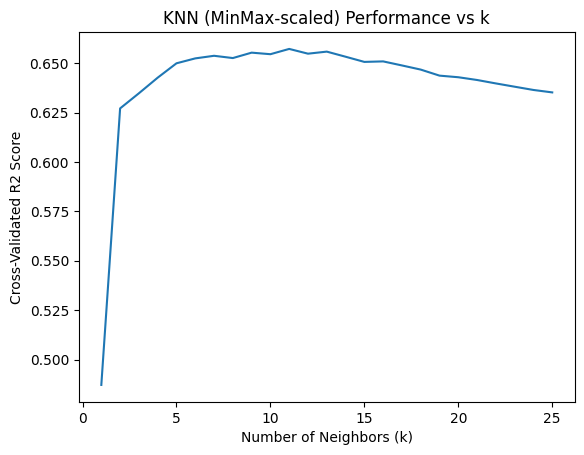

Best k: 11 Best CV R2: 0.6571704043326225


In [9]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

# X / y
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Rescale (0-1)
scaler = MinMaxScaler()
X_rescaled = scaler.fit_transform(X)

# Tune k = 1..25 with CV R2
k_values = range(1, 26)
scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    r2 = cross_val_score(knn, X_rescaled, y, cv=5, scoring="r2").mean()
    scores.append(r2)

# Plot score evolution
plt.figure()
plt.plot(list(k_values), scores)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated R2 Score")
plt.title("KNN (MinMax-scaled) Performance vs k")
plt.show()

#  en iyi k ve skor
best_k = list(k_values)[scores.index(max(scores))]
best_score = max(scores)
print("Best k:", best_k, "Best CV R2:", best_score)

❓ K'nın hangi değeri en iyi performansı üretir? Cevabınızı `best_k` değişken adı altında kaydedin.

In [8]:
best_score=best_k
best_k


11

<details>
<summary> 👉 Çözüm 👈</summary>
    
Grafiğinize bakarak, skorun k = 5 civarında artmayı durdurduğunu ve maksimum skorun k = 11 için ulaşıldığını görmelisiniz.

</details>

❓ $k$ < 5 değerleri için modelin kötü performansını nasıl yorumluyorsunuz?

<details>
<summary> 👉 Çözüm 👈</summary>
    
K çok küçük olduğunda, model eğitim kümesine aşırı uyum gösterme eğiliminde olacaktır. İyi genelleştirebilmek için çok az noktaya odaklanacaktır. K'yı artırmak modele tahminlerini dayandıracağı daha fazla örnek verecektir.

</details>

### 🧪 Kodunuzu kontrol edin

In [10]:
from nbresult import ChallengeResult

result = ChallengeResult('optimal_k',
                         optimal_k = best_k)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/mcelik/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/mcelik/code/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_optimal_k.py::TestOptimal_k::test_optimal_K_around_10 PASSED        [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/optimal_k.pickle

git commit -m 'Completed optimal_k step'

git push origin master



# KNN'de Aşırı Uyum

💡 KNN'lerin K parametresi çok küçük olduğunda, eğitim kümesine aşırı uyum gösterme ve iyi genelleştirememe riski vardır. 

👇 K=2 parametreli bir KNN'in öğrenme eğrilerini çizin.

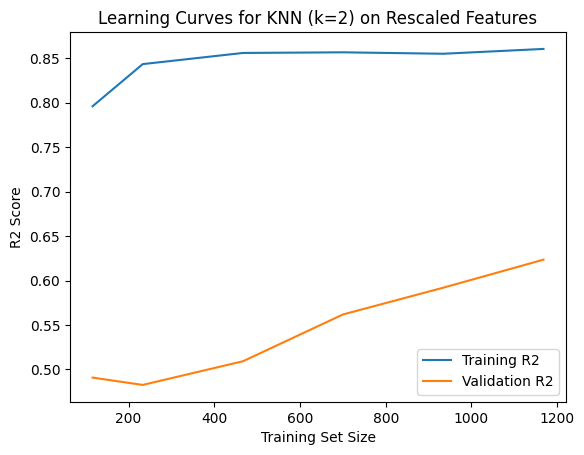

In [13]:
from sklearn.model_selection import learning_curve
# Rescale (0-1)
scaler = MinMaxScaler()
X_rescaled = scaler.fit_transform(X)

# KNN with k=2
knn_k2 = KNeighborsRegressor(n_neighbors=2)

# Learning curve (R2, 5-fold CV)
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=knn_k2,
    X=X_rescaled,
    y=y,
    cv=5,
    scoring="r2",
    train_sizes=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Ortalama skorlar
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_mean, label="Training R2")
plt.plot(train_sizes, valid_mean, label="Validation R2")
plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title("Learning Curves for KNN (k=2) on Rescaled Features")
plt.legend()
plt.show()

👉 Yüksek eğitim skoru ama düşük test skoru gözlemlemelisiniz. ⚠️ Aşırı uyum uyarısı ⚠️ Bu çok düşük K parametresinden kaynaklanır.

# İdeal K

👇 Bu sefer, "$k$ Optimizasyonu" bölümünde bulduğunuz ideal K değeri için öğrenme eğrilerini çizin.

Best k: 11 Best CV R2: 0.6571704043326225


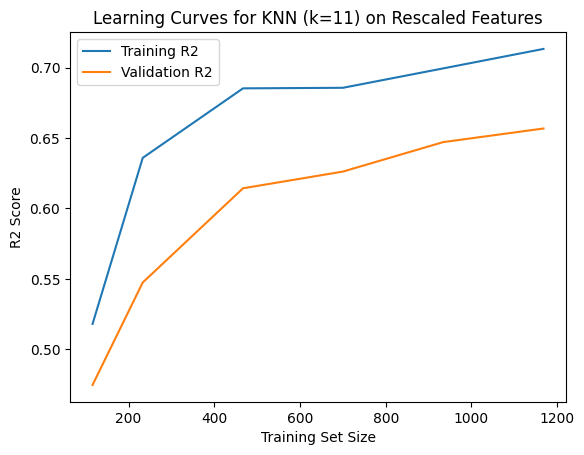

In [14]:
# ---- k optimization (1..25) to find ideal k ----
k_values = range(1, 26)
scores = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    r2 = cross_val_score(knn, X_rescaled, y, cv=5, scoring="r2").mean()
    scores.append(r2)

best_k = list(k_values)[scores.index(max(scores))]
print("Best k:", best_k, "Best CV R2:", max(scores))

# ---- learning curve for best_k ----
knn_best = KNeighborsRegressor(n_neighbors=best_k)

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=knn_best,
    X=X_rescaled,
    y=y,
    cv=5,
    scoring="r2",
    train_sizes=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training R2")
plt.plot(train_sizes, valid_mean, label="Validation R2")
plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title(f"Learning Curves for KNN (k={best_k}) on Rescaled Features")
plt.legend()
plt.show()

👉 Eğriler yakınsamaya yakın olmalı, bu da modelin daha az aşırı uyum gösterdiğini ve daha iyi genelleştirdiğini gösterir.

💡 KNN modelleriyle modelleme yaparken hatırlanması gereken iki temel unsur vardır:  
    1. Mesafe tabanlı algoritmalar özelliklerin ölçeğine son derece duyarlıdır  
    2. K ayarlanmalıdır: performans, genelleştirme ve aşırı uyum arasındaki dengeyi kontrol eder

❓ Optimize edilmiş KNN modelinin gerçek fiyat ile tahmin edilen fiyat arasındaki ortalama fark nedir? Cevabınızı hesaplayın ve `price_error` değişken adı altında kaydedin

<details>
<summary> 💡 İpucu </summary>
    
Hesaplamanız gereken metrik **Negatif Ortalama Mutlak Hata (MAE)**'dır.

</details>

In [15]:
# ---- 1) Find best k by CV R2 (k=1..25) ----
k_values = range(1, 26)
r2_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    r2 = cross_val_score(knn, X_rescaled, y, cv=5, scoring="r2").mean()
    r2_scores.append(r2)

best_k = list(k_values)[r2_scores.index(max(r2_scores))]

# ---- 2) Compute Negative MAE for optimized model ----
knn_best = KNeighborsRegressor(n_neighbors=best_k)

# Negatif MAE (sklearn böyle döndürür)
price_error = cross_val_score(
    knn_best,
    X_rescaled,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
).mean()

print("best_k:", best_k)
print("price_error (neg MAE):", price_error)
print("MAE (avg absolute price difference):", -price_error)

best_k: 11
price_error (neg MAE): -30823.53430884184
MAE (avg absolute price difference): 30823.53430884184


### 🧪 Kodunuzu kontrol edin

In [16]:
from nbresult import ChallengeResult

result = ChallengeResult('price_error',
                         error = price_error)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/mcelik/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/mcelik/code/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_price_error.py::TestPrice_error::test_price_error_range PASSED      [100%]

============================== 1 passed in 0.27s ===============================


💯 You can commit your code:

git add tests/price_error.pickle

git commit -m 'Completed price_error step'

git push origin master



# Model Seçimi

❓ Ev fiyatlarını tahmin etme görevini gerçekleştirmek için bu iki modelden hangisini seçersiniz:
- Az önce ayarladığınız KNN modeli
- Bir Linear Regression modeli

Cevabınızı "KNN" veya "LinearReg" olarak `best_model` değişken adı altında string olarak kaydedin.

<details>
<summary> 💡 İpucu </summary>
    
Hangisini seçeceğinize karar vermek için, aynı görev üzerinde bir Linear Regression skorunu değerlendirmeniz ve KNN'in skoruyla karşılaştırmanız gerekecek. Aynı metrikleri karşılaştırdığınızdan emin olun!!

</details>

In [20]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression



X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Rescale features (same input for both models)
scaler = MinMaxScaler()
X_rescaled = scaler.fit_transform(X)

# Models
knn = KNeighborsRegressor(n_neighbors=11)   # optimized k
lin = LinearRegression()

# Compare with SAME metrics
knn_r2  = cross_val_score(knn, X_rescaled, y, cv=5, scoring="r2").mean()
lin_r2  = cross_val_score(lin, X_rescaled, y, cv=5, scoring="r2").mean()

knn_neg_mae = cross_val_score(knn, X_rescaled, y, cv=5, scoring="neg_mean_absolute_error").mean()
lin_neg_mae = cross_val_score(lin, X_rescaled, y, cv=5, scoring="neg_mean_absolute_error").mean()

knn_mae = -knn_neg_mae
lin_mae = -lin_neg_mae

print("KNN  (k=11)  R2:", knn_r2, "MAE:", knn_mae)
print("LinearReg    R2:", lin_r2, "MAE:", lin_mae)

# Pick best model (use SAME metric; here I prioritize R2 as in earlier tasks)
best_model = "KNN" if knn_r2 >= lin_r2 else "LinearReg"
best_model

KNN  (k=11)  R2: 0.6571704043326225 MAE: 30823.53430884184
LinearReg    R2: 0.5944790982110585 MAE: 33586.16906310637


'KNN'

💡 Her iki modelin metriklerini karşılaştırdığınızda, KNN modeli Linear Regression'ı geçmelidir. Bu, verideki doğrusal olmayan kalıpları yakalama yeteneğinden kaynaklanabilir.

### 🧪 Kodunuzu kontrol edin

In [21]:
from nbresult import ChallengeResult

result = ChallengeResult('best_model',
                         model = best_model)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/mcelik/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/mcelik/code/S16D1-S-data-knn/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_best_model.py::TestBest_model::test_best_model PASSED               [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/best_model.pickle

git commit -m 'Completed best_model step'

git push origin master



# 🏁